# Статистические тесты

## Тест пропорций

In [14]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

In [15]:
control_results = ab_test[ab_test['group'] == 'control']['converted']
treatment_results = ab_test[ab_test['group'] == 'treatment']['converted']

In [16]:
n_con = control_results.count()  ## количество не пустых значений в контрольной группе?
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]  ## количество успешных конверсий в каждой группе
nobs = [n_con, n_treat]  ## количество значений в каждой группе

z_stat, pval = proportions_ztest(successes, nobs=nobs)  ## z-тест сравнение пропорций в дух группах
(lower_con, lower_treat), (upper_con, upper_treat) = proportion_confint(successes, nobs=nobs, alpha=0.05)

print(f'z statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')
print(f'ci 95% for control group: [{lower_con:.3f}, {upper_con:.3f}]')
print(f'ci 95% for treatment group: [{lower_treat:.3f}, {upper_treat:.3f}]')

z statistic: -0.34
p-value: 0.732
ci 95% for control group: [0.114, 0.133]
ci 95% for treatment group: [0.116, 0.135]


In [24]:
import numpy as np
import pandas as pd

In [146]:
# сгенерируем данные
group_A_size = 1000
group_A_conversion = 0.12 
group_B_size = 1000
group_B_conversion = 0.15 

group_A_data = pd.DataFrame({
    'group': ['A'] * group_A_size, 
    'converted': (
            np.random
            .RandomState(42)
            .choice(2, size=group_A_size, replace=True, p=[1 - group_A_conversion, group_A_conversion])),
})

group_B_data = pd.DataFrame({
    'group': ['B'] * group_B_size, 
    'converted': (
            np.random
            .RandomState(42)
            .choice(2, size=group_B_size, replace=True, p=[1 - group_B_conversion, group_B_conversion])),
})
df = pd.concat([group_A_data, group_B_data])

df[df.group == 'A'].converted.mean(), df[df.group == 'B'].converted.mean()

(0.124, 0.153)

In [8]:
from statsmodels.stats.proportion import proportions_ztest

# Пример данных
converted_A = 120  # число конверсий в группе A
n_A = 1000         # общее число пользователей в группе A
converted_B = 150  # число конверсий в группе B
n_B = 1000         # общее число пользователей в группе B

In [10]:
# Собираем данные в массивы
conversions = np.array([converted_A, converted_B])
sample_sizes = np.array([n_A, n_B])

# Двусторонний Z-тест для пропорций
z_stat, p_value = proportions_ztest(count=conversions, nobs=sample_sizes, alternative='two-sided')

# Односторонний тест (что группа B лучше группы A)
z_stat_one_sided, p_value_one_sided = proportions_ztest(count=conversions, nobs=sample_sizes, alternative='larger')

In [12]:
from statsmodels.stats.proportion import proportion_confint

# Доверительные интервалы для каждой группы
ci_A = proportion_confint(count=converted_A, nobs=n_A, alpha=0.05, method='normal')
ci_B = proportion_confint(count=converted_B, nobs=n_B, alpha=0.05, method='normal')

# Относительное изменение конверсии
rel_change = (converted_B/n_B)/(converted_A/n_A) - 1

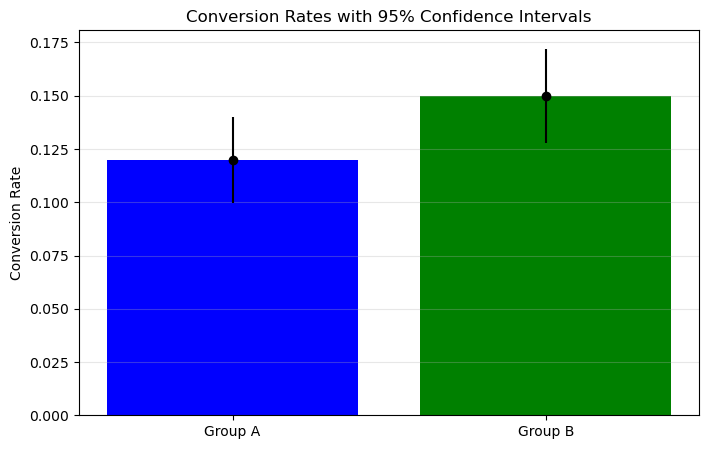

In [14]:
import matplotlib.pyplot as plt

# Конверсии в каждой группе
conv_rates = [converted_A/n_A, converted_B/n_B]
groups = ['Group A', 'Group B']

plt.figure(figsize=(8, 5))
plt.bar(groups, conv_rates, color=['blue', 'green'])
plt.errorbar(groups, conv_rates, 
             yerr=[conv_rates[0]-ci_A[0], conv_rates[1]-ci_B[0]], 
             fmt='o', color='black')
plt.title('Conversion Rates with 95% Confidence Intervals')
plt.ylabel('Conversion Rate')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [16]:
print(f"Конверсия группы A: {converted_A/n_A:.4f} ({ci_A[0]:.4f}-{ci_A[1]:.4f})")
print(f"Конверсия группы B: {converted_B/n_B:.4f} ({ci_B[0]:.4f}-{ci_B[1]:.4f})")
print(f"Относительное изменение: {rel_change:.2%}")
print(f"\nДвусторонний p-value: {p_value:.4f}")
print(f"Односторонний p-value: {p_value_one_sided:.4f}")

if p_value < 0.05:
    print("\nВывод: Есть статистически значимая разница между группами")
    if converted_B/n_B > converted_A/n_A:
        print("Группа B показала лучший результат")
    else:
        print("Группа A показала лучший результат")
else:
    print("\nВывод: Нет статистически значимой разницы между группами")

Конверсия группы A: 0.1200 (0.0999-0.1401)
Конверсия группы B: 0.1500 (0.1279-0.1721)
Относительное изменение: 25.00%

Двусторонний p-value: 0.0496
Односторонний p-value: 0.9752

Вывод: Есть статистически значимая разница между группами
Группа B показала лучший результат


In [22]:
# Рассчет мощности теста
from statsmodels.stats.power import tt_ind_solve_power
import statsmodels.stats.proportion as smp

effect_size = smp.proportion_effectsize(converted_A/n_A, converted_B/n_B)
power = tt_ind_solve_power(effect_size=effect_size, nobs1=n_A, alpha=0.05, ratio=n_B/n_A)
print(f"\nМощность теста: {power:.2f}")

# Необходимый размер выборки для заданного эффекта
required_n = smp.samplesize_proportions_2indep_onetail(
    diff=(converted_B / n_B - converted_A / n_A), 
    prop2=converted_B/n_B, 
    power=0.8,
    ratio=1,
    alpha=0.05, 
    alternative='two-sided',
)
print(f"Необходимый размер выборки для power=0.8: {required_n:.0f} на группу")


Мощность теста: 0.50
Необходимый размер выборки для power=0.8: 2402 на группу
